# 3.1 Понятие корреляции

## Основные определения и тезисы:
**Ковариация(cov)** - количественный показатель силы и направления взаимосвязи переменных. Если ковариация положительна, то с ростом значений одной случайной величины, значения второй имеют тенденцию возрастать, а если знак отрицательный — то убывать.  
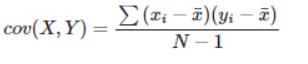

**Корреляция** - мера степени взаимосвязи между двумя переменными. Позволяет определить, **насколько сильно** две переменные связаны друг с другом, а также направление этой взаимосвязи.  

Поскольку масштаб ковариации зависит от дисперсий величин. Значения ковариации можно нормализировать, поделив её на произведение среднеквадратических отклонений (квадратных корней из дисперсий) случайных величин. Полученная величина называется **коэффициентом корреляции Пирсона**, который всегда находится в интервале от −1 до 1:  
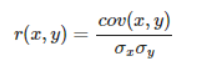

**Коэффициент корреляции(r)** принимает значения от -1 до 1. Значение -1 означает, что между двумя переменными существует полная обратная корреляция, т.е. когда одна переменная увеличивается, другая уменьшается. Значение 1 означает, что между переменными существует полная прямая корреляция, т.е. когда одна переменная увеличивается, другая также увеличивается. Значение 0 означает, что между переменными нет корреляции. Чем **ближе** значение коэффициента корреляции к 1 или к -1, тем **сильнее** взаимосвязь двух переменных.  

**Коэффициент детерминации(R²)** = квадрату коэффициента корреляции. Показывает, в какой степени дисперсия одной переменной обусловлена влиянием ругой переменной. Принимает значения от 0 до 1. Значение 0 означает, что модель не объясняет никакой вариации в данных, а значение 1 означает, что модель объясняет всю вариацию в данных. Высокое значение коэффициента детерминации указывает на то, что модель регрессии хорошо соответствует данным и может быть использована для прогнозирования.   

**Диаграмма рассеивания** - Данные представляются в виде точек на графике, где каждая точка представляет собой наблюдение для двух переменных. Одна переменная обычно отображается по оси X, а другая переменная - по оси Y.  

*Поскольку сравниваются 2 переменные, то df = N - 2*

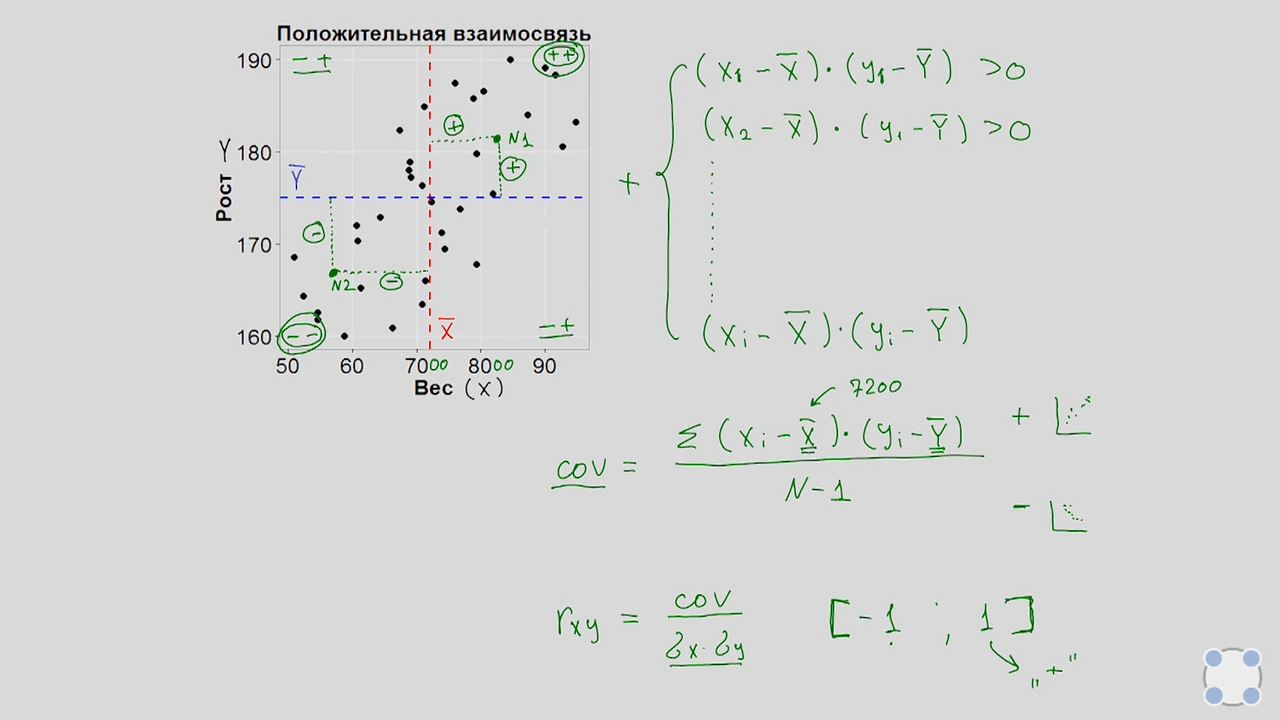

## Пример

In [11]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

X = [4,5,2,3,1]
Y = [2,1,4,3,5]

In [31]:
print(stats.pearsonr(X, Y))
print(np.corrcoef(X, Y))

PearsonRResult(statistic=-1.0, pvalue=0.0)
[[ 1. -1.]
 [-1.  1.]]


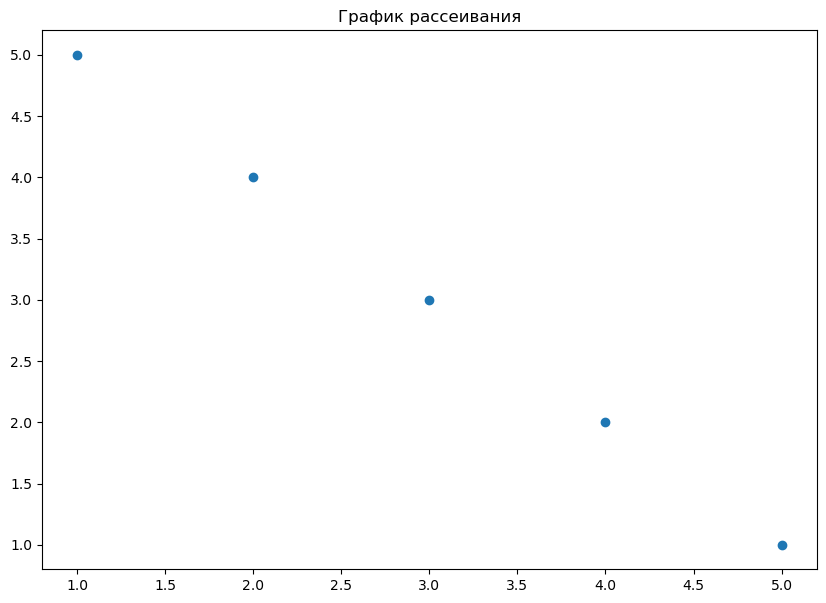

In [15]:
fig = plt.figure(figsize = (10,7))
plt.scatter(X, Y)
plt.title(label = 'График рассеивания')
plt.show()

# 3.2 Условия применения коэффициента корреляции

## Основные определения и тезисы:
### Ограничения для использования r:  
1) **Характер взаимосвязи** - должен быть **линейный и монотонный**(одна прямая линия на диаграмме рассеивания). В данных случаях с помощью коэффициента корреляции интерпретировать данные нельзя:
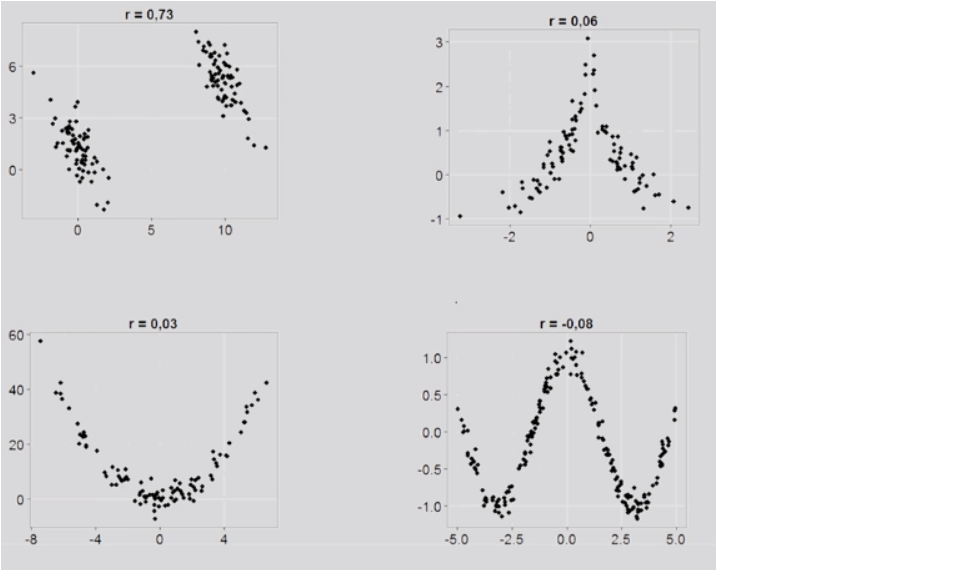

3) **Распределение** - распределение данных должно стремиться к **нормальному**. Поскольку при рассчете корреляции используется среднее значение, выбросы, ассиметрия, бимодальность и т. д. могут сильно исказить значение **r**. На картинке слева - коэффициент корреляции без выбросов, справа - то же распределение, но с 2 выбросами:  
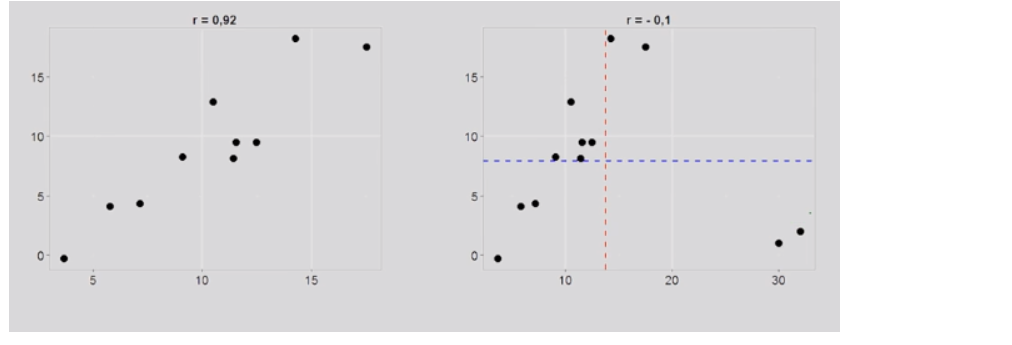  

### Непараметрические аналоги r:
* **Коэфициент корреляции Спирмана** - Выбросы не так сильно искажают **r**, т.к. используются ранговые значения. Ранжируются значения x и y, затем вычисляются их **разности рангов(d^2)**.
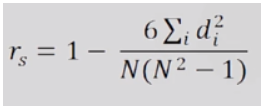
*где d^2 - разность рангов возведённая в квадрат - (X - Y)^2*  
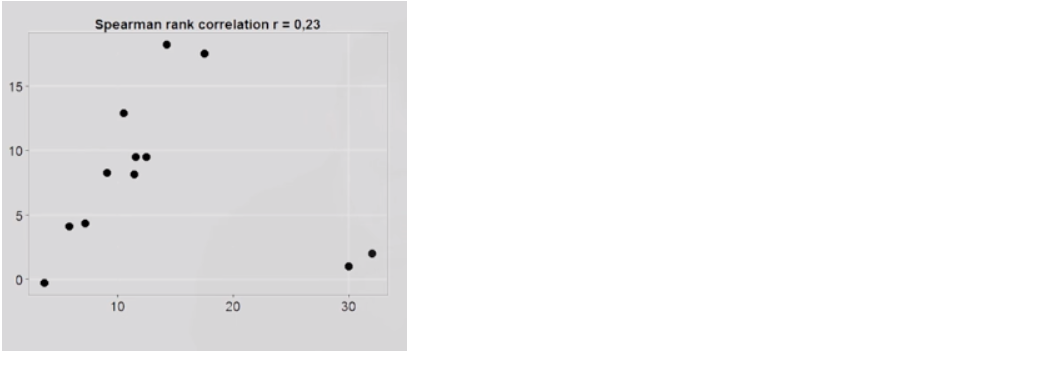 

* **Коэфициент корреляции тау(τ) Кендалла**  

**Корреляционная ошибка** - положительная или отрицательная взаимосвязь между переменными еще не говорит о причинно-следственной зависимости.  
**Влияние третьей переменной** - связь между двумя переменными может быть занижена или завышена из-за влияния третьей переменной, которая может влиять на обе переменные. Для учета влияния третьей переменной в корреляционном анализе обычно используют множественную регрессию.

# Пример расчет коэффициента корреляции Спирмана

In [40]:
# пара наблюдений
X = np.array([3.7, 5.8, 7.1, 9.1, 10.5, 11.4, 11.6, 12.5, 14.3, 17.5, 30.0, 32.0])
Y = np.array([-0.3, 4.1, 4.3, 8.3, 12.9, 8.1, 9.5, 9.5, 18.2, 17.5, 1.0, 2.0])

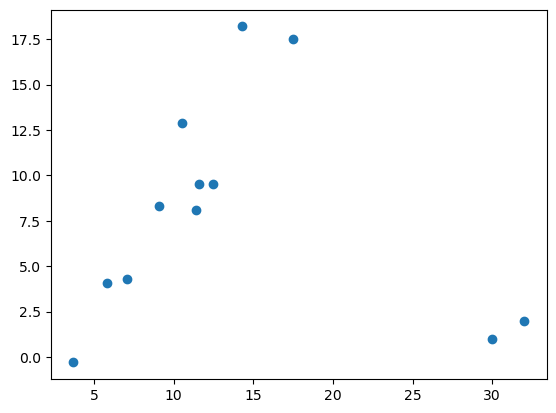

In [42]:
plt.scatter(X, Y)
plt.show()

In [46]:
r_s = 1 - (6 * sum((stats.rankdata(X, method='ordinal')
           - stats.rankdata(Y, method='ordinal')) ** 2)) / (len(X) * ((len(X) ** 2 - 1)))
print('Коэффициент корреляции Спирмана:', r_s)

Коэффициент корреляции Спирмана: 0.2447552447552448


In [48]:
print(stats.spearmanr(X, Y))

SignificanceResult(statistic=0.24168163157672948, pvalue=0.4491887440384277)


# 3.3 Регрессия с одной независимой переменной

## Основные определения и тезисы:


**Одномерный регрессионный анализ** - используется для изучения связи между двумя количественными переменными, когда одна переменная является зависимой(**y**), а другая - независимой(predict или **x**). Задача одномерной регрессии заключается в том, чтобы найти уравнение линейной зависимости между этими двумя переменными.  

**Линия регрессии** - представляет собой прямую линию, которая наилучшим образом описывает зависимость между двумя переменными в одномерной линейной регрессии. Эта прямая строится на основе коэффициентов β0 и β1:  

**y = b0 + b1x**  
где b0 - свободный член(intersept), отвечает за то, где прямая пересекает ось y;  
b1 - это коэффициент наклона(slope) - угловой коэффициент c осью x;  
x- это известное значение независимой переменной.  

**Метод наименьших квадратов(МНК)** - метод нахождения оптимальных параметров линейной регрессии(b0, b1), таких, чтобы сумма квадратов  ошибок(сумма квадратов остатков - **Σe^2**) была минимальна.  
Для каждой из точек рассчитывают расстояние(по оси y) до регрессионной прямой(синяя и краснаяя линия) - это расстояние и есть **остаток(e)**.  

**e1 = y1 - y1'**  
где y1 - фактическое значение зависимой переменной;  
y1' - прогнозные значения зависимой переменной(на прямой), которые рассчитываются на основе уравнения модели.  

Суть: найти такие параметры линейной регрессии, чтобы все точки находились максимально близко к ней.  

Коэффициенты рассчитываются следующим образом:  
**b1 = (sdy / sdx) * rxy** - sd - стандартное отклонение, r - коэфициент корреляции.  
**b0 = y_mean - b1 * x_mean**  

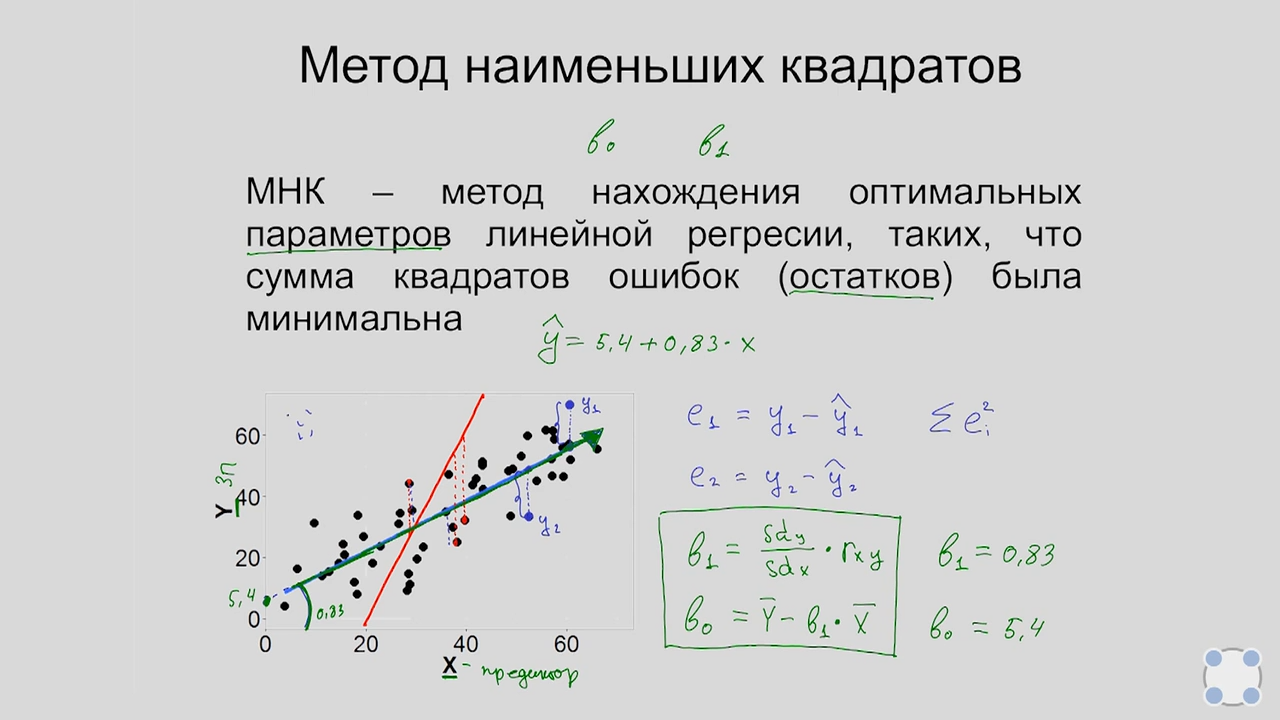

In [68]:
# Рассчитайте коэффициент b1 для регрессионной прямой, если коэффициент детерминации равен 0,25:
# Дано: среднее дисперсия и коэффициент детерминации
mean_x = 15
D_x = 25
mean_y = 10
D_y = 36
R = 0.25

# стандартное отклонение
sd_x = D_x**0.5
sd_y = D_y**0.5

# коэффициент корреляции
r = R**0.5

b1 = sd_y / sd_x * r
b1

0.6

## Пример регрессии с одной независимой переменной

b0 = 79.79541814094563, b1 = 1.2698472503162554


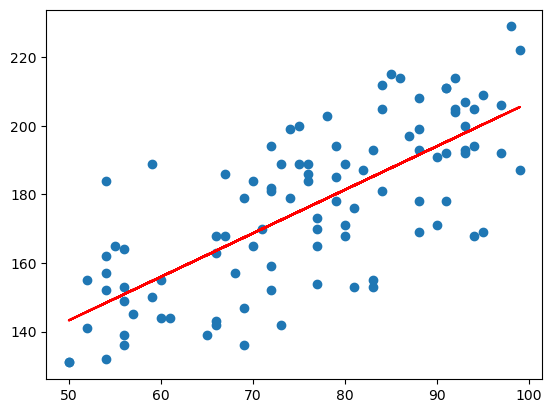

In [73]:
N = 100

# случайные значения x и y
x = np.array([np.random.randint(50,100) for i in range(N)])
y = np.array([i+np.random.randint(80,120)-np.random.randint(-20,20) for i in x])

# рассчет коэффициентов
# b1 = y.std()/x.std()*cor(x, y)
# b0 = y.mean() - b1*x.mean()
b1, b0 = np.polyfit(x, y, 1) #  b0 - intercept, b1 - slope
print(f"b0 = {b0}, b1 = {b1}")

# функция линейной регрессии
f = lambda x: b0 + b1*x
y_pred = f(x)

# график
plt.scatter(x, y)
plt.plot(x, y_pred, color='red')
plt.show()

# 3.4 Гипотеза о значимости взаимосвязи и коэффициент детерминации

## Основные определения и тезисы:
Нулевая гипотеза в одномерном регрессионном анализе заключается в том, что между зависимой переменной **y** и независимой переменной **x** не существует значимой линейной связи. Иными словами, H0 отрицает наличие любой связи между **x** и **y**, и предполагает, что изменения **x** не приводят к изменениям **y**.  
H0 может быть сформулирована следующим образом:  
**H0: b1 = 0** , тогда  
**H0: b1 ≠ 0**  

Если многократно повторять эксперимент когда верна H0, то b1 распределились относительно нормальным образом вокруг 0 с отклонением в обе стороны. Тогда: **t-критерий** = (b1 - 0) / se  = b1/se  
*0 - ожидаемое среднее ГС*  
**df** = N - 2
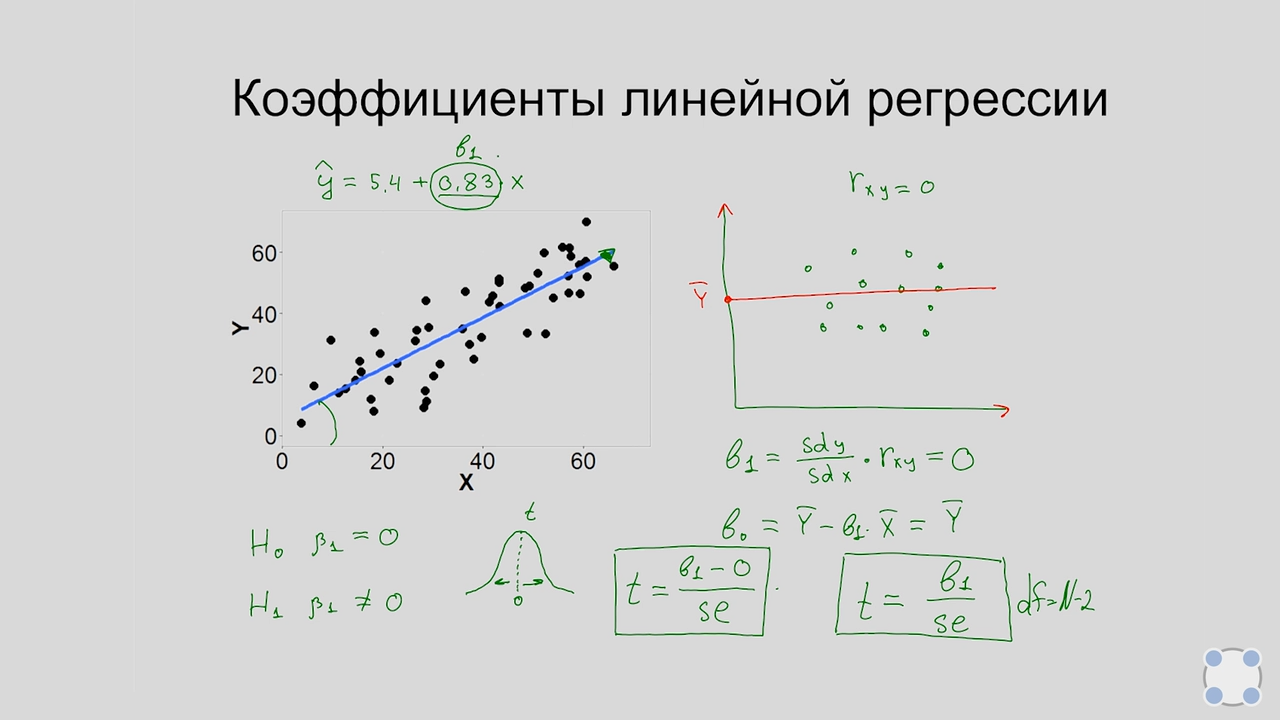

Отклонив H0, о том что b1 = 0, мы можем сделать вывод, что обнаружена **значимая** взаимосвязь двух переменных.

**Коэффициент детерминации R^2** - доля зависимой переменной **y**, которая "объясняется" полученной регрессионной моделью. Чем больше R^2, тем лучше модель справляется с задачей.  
**R^2 = 1 - (SSres / SStotal)**  
где SSres сумма квадратов остатков(сумма расстояний от наблюдений до прямой в квадрате - синяя линия на рисунке),  
SStotal - сумма квадратов общая(сумма расстояний от наблюдений до среднего значения - красная линия на рисунке).  
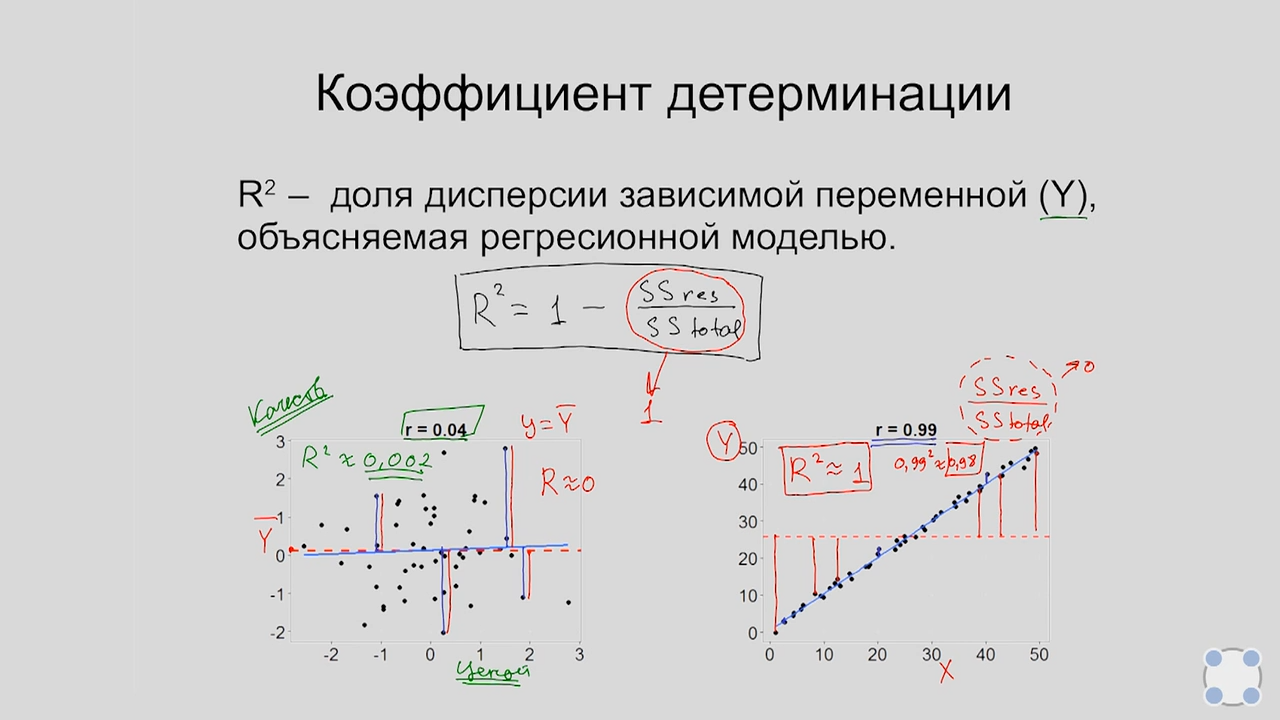

Если коэффициент детерминации равен нулю, то и коэффициент b1 (slope) также равен нулю. Так как зависимость между Dxy() и b1 имеет вид:  
b1 = (sdx * R^2) / sdy

## Линейная регрессия через statsmodels 

In [94]:
import statsmodels.api as sm

X = np.array([[1], [2], [3], [4], [5]])  # независимая переменная
y = np.array([2, 4, 5, 4, 5])            # зависимая переменная
# Добавляем константу (intercept)
X = sm.add_constant(X)
# Создаем и обучаем модель
model_sm = sm.OLS(y, X).fit()
#Выводим статистику
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.600
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     4.500
Date:                Thu, 03 Jul 2025   Prob (F-statistic):              0.124
Time:                        17:13:26   Log-Likelihood:                -5.2598
No. Observations:                   5   AIC:                             14.52
Df Residuals:                       3   BIC:                             13.74
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2000      0.938      2.345      0.1

D:\Anaconda\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


# 3.5 Условия применения линейной регрессии с одним предиктором

## Основные определения и тезисы:  
**Условия применения:**  
1) Линейная взаимосвязь **x** и **y**. В случае линейной взаимосвязи двух переменных распределение остатков будет стремиться к нормальному со средним значением, приблизительно равным нулю;
Линейная взаимосвязь переменных. В данном случае соблюдены условия применения линейной регрессии.
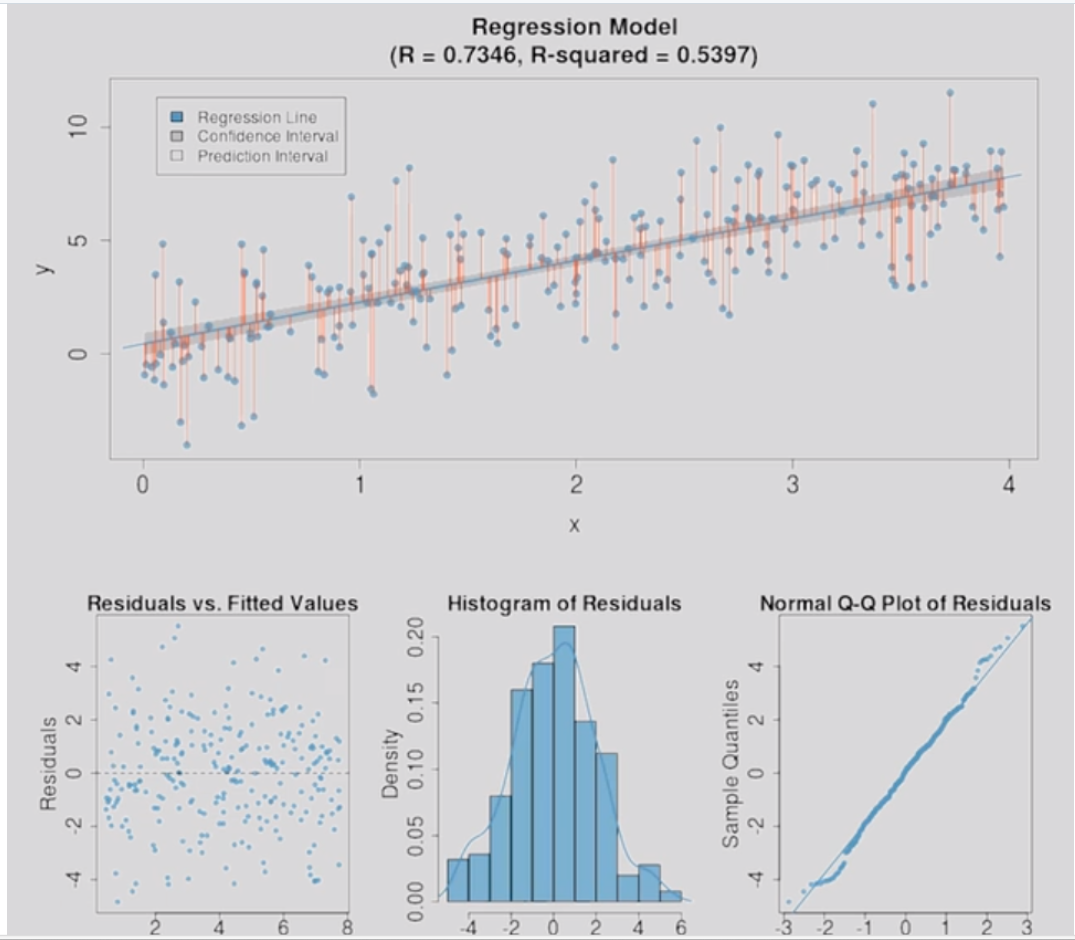
2) Нормальное распределение остатков;
4) Гомоскедастичность - постоянная изменчивость остатков на всех уровнях независимой переменной. Если остатки имеют постоянную дисперсию по всем значениям независимой переменной, то говорят, что модель гомоскедастична.
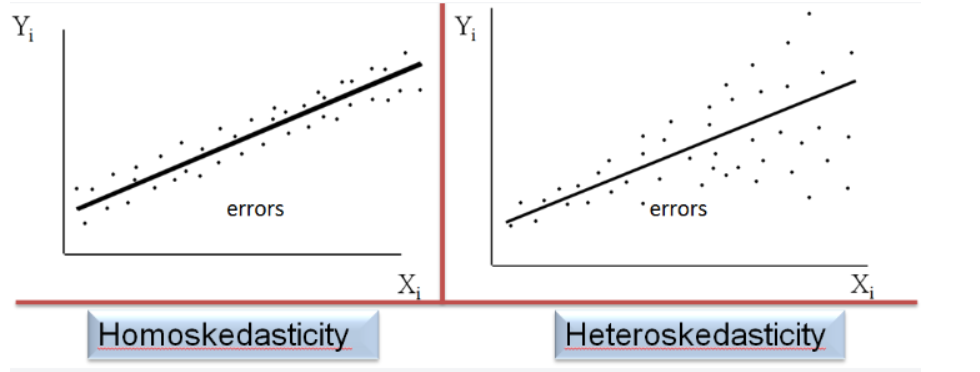

# 3.6 Применение регрессионного анализа и интерпретация результатов

## Данные:  
* state - название штата
* metro_res - какое % населения штата живет в столичной области;
* white - % белокожего населения;
* hs_grad - % населения имеющего среднее образование;
* poverty - % людей проживающих в бедности;
* female_house - % семей, в которых женщины - домохозяйки. 

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [455]:
URL = "http://d396qusza40orc.cloudfront.net/statistics/lec_resources/states.csv"
state_data = pd.read_csv(URL)
state_data.head()

,state,metro_res,white,hs_grad,poverty,female_house
0,Alabama,55.4,71.3,79.9,14.6,14.2
1,Alaska,65.6,70.8,90.6,8.3,10.8
2,Arizona,88.2,87.7,83.8,13.3,11.1
3,Arkansas,52.5,81.0,80.9,18.0,12.1
4,California,94.4,77.5,81.1,12.8,12.6


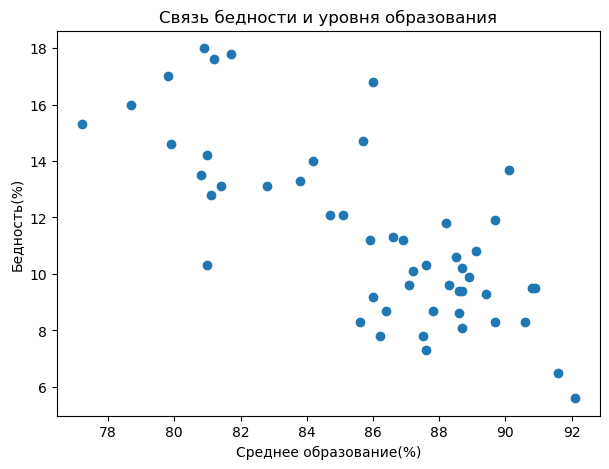

In [457]:
"""Регрессионный анализ с одной независимой переменной.
   Исследование взаимосвязи бедности и наличия среднего образования"""
# среднее образование - независиммая переменная - predictor
X = state_data['hs_grad']
# бедность - зависимая переменная
y = state_data['poverty']

# визуализация взаимосвязи переменных
fig = plt.figure(figsize=(7,5))
plt.scatter(X, y)

# заголовки графика и осей
plt.title("Связь бедности и уровня образования")
plt.xlabel("Cреднее образование(%)")
plt.ylabel("Бедность(%)")
plt.show()

In [459]:
state_data_descr = state_data.describe().transpose()
state_data_descr[2:4]

,count,mean,std,min,25%,50%,75%,max
hs_grad,51.0,86.011765,3.725998,77.2,83.30,86.9,88.7,92.1
poverty,51.0,11.349020,3.099185,5.6,9.25,10.6,13.4,18.0


In [461]:
cor_pearson = stats.pearsonr(state_data['hs_grad'], state_data['poverty'])[0]
cor_pearson

-0.7468582531582508

По графику видно, что переменные имеют линейную отрицательную взаимосвязь (корреляция r = -0.746).  
Поскольку взаимосвязь линейная, для анализа можно использовать линейную регрессионную модель.  
Далее выполняется следующий алгоритм:  
1) Строится регрессионная модель: y = b0 + b1x;  
2) Высчитывается с помощью коэффициента детерминации(R), насколько хорошо модель объясняет взаимосвязь переменных. Рассматривается нулевая гипотеза:  b1 = 0 : H0;  
3) Задача предсказания: как, основываясь на независимой переменной, можно предсказать значения зависимой переменной(См. главу 3.7).

b1 = -0.6212167177940104, b0 = 64.78096577010209


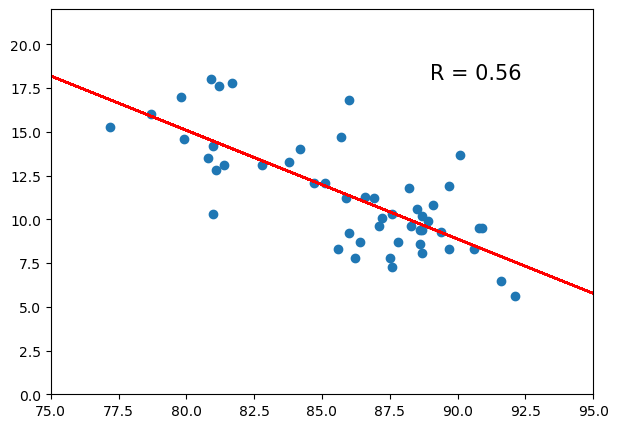

In [464]:
# рассчет slope, intersept
b1, b0 = np.polyfit(X, y, 1) #  b0 - intercept, b1 - slope
print(f'b1 = {b1}, b0 = {b0}')
# функция линейной регрессии
f = lambda x: b0 + b1*x
y_pred = f(x)
# график
fig = plt.figure(figsize=(7,5))
plt.scatter(X, y)
plt.plot(x, y_pred, color='red')
plt.xlim(75, 95)
plt.ylim(0, 22)

R = cor_pearson**2
plt.text(x=89, y=18, s=f'R = {round(R, 2)}', fontsize=15)
plt.show()

In [466]:
import statsmodels.formula.api as sm
result = sm.ols('poverty ~ hs_grad', data=state_data).fit()

print(result.params)
print(result.summary())

Intercept    64.780966
hs_grad      -0.621217
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                poverty   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     61.81
Date:                Sun, 06 Jul 2025   Prob (F-statistic):           3.11e-10
Time:                        12:48:59   Log-Likelihood:                -108.74
No. Observations:                  51   AIC:                             221.5
Df Residuals:                      49   BIC:                             225.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

**Таким образом, при увеличении процента образования на 1 единицу, уровень бедности падает на 0,62 единицы(% в нашем случае)**

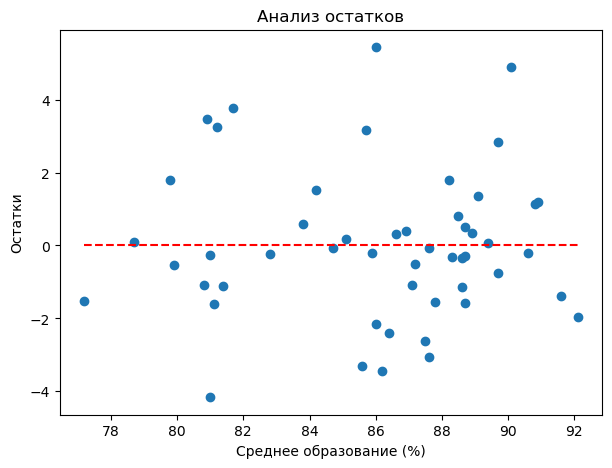

In [469]:
residuals = y - (b0 + b1*X)
fig = plt.figure(figsize = (7,5))
plt.scatter(X, residuals)
x1 = np.linspace(min(X),max(X),len(X))
plt.plot(x1, [0]*len(x1),'--r')
plt.title('Анализ остатков')
plt.xlabel('Среднее образование (%)')
plt.ylabel('Остатки')
plt.show()

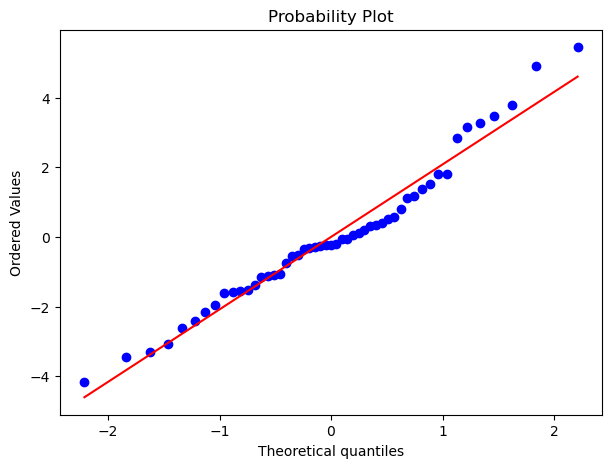

In [473]:
fig = plt.figure(figsize = (7,5))
stats.probplot(residuals, dist='norm', plot=plt)
plt.show()

# 3.7 Задача предсказания значений зависимой переменной

## Основные определения и тезисы:   
Основываясь на линии тренда(линии регрессионной прямой), можно предсказать чему будут равны значения зависимой переменной при определенном значении независимой переменной.  
Для предсказания нужно определить что регрессионная модель достаточно надежно и может хорошо описать взаимосвязь двух переменных. Необходимо быть уверенным в том, что:  
1) линейность сохранится;  
2) нормальность остатков сохранится;  
3) гомоскадентичность не изменится.

In [475]:
"""Основываясь на нашей регрессионной модели poverty = 64.78 - 0.62 * hs_grad, 
   какой процент населения, проживающего в бедности, ожидался бы при уровне среднего образования, равного 62%"""
X = 62
y = (b0 + b1*X)
y

26.265529266873436

# 3.8 Регрессионный анализ с несколькими независимыми переменными

### Основные определения и тезисы:   
**Множественная регрессия** позволяет исследовать влияние сразу нескольких независимых переменных на одну зависимую. Тогда уравнение модели примет вид:  
**y = b0 + b1x1 + b2x2**  - уравнение с двумя независимыми переменными(x1,x2)
или  
**y = b0 +b1x1 + ... + bnxn** - уравнение с n независимыми переменными.  

**Требования к данным**:  
* Линейная зависимость переменных;
* Нормальное распределение остатков;
* Гомоскедастичность;
* Проверка на мультиколлинеарность(см. 3.9);
* Нормальное распределение переменных(чем ближе к нормальному - тем лучше).  

Множественная регрессия позволяет исключить факт того, что 2 переменные связаны между собой только за счет 3 переменной(позволяет установить индивидуальную связь 2-ух переменных).

In [479]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm

## Пример расчета модели

In [482]:
"""Пример расчета модели, если туда 'вложить' все независимые переменные из таблицы"""

URL = "http://d396qusza40orc.cloudfront.net/statistics/lec_resources/states.csv"
state_data = pd.read_csv(URL)

result = sm.ols(formula="poverty ~ metro_res + white + hs_grad + female_house", data=state_data).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                poverty   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     20.58
Date:                Sun, 06 Jul 2025   Prob (F-statistic):           8.88e-10
Time:                        12:49:15   Log-Likelihood:                -103.39
No. Observations:                  51   AIC:                             216.8
Df Residuals:                      46   BIC:                             226.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       66.4765     12.590      5.280   

**Intersept-coef(b0)** - чему, по ожиданиям, равнялся бы % людей проживающих в бедности, если допустить, что все остальные переменные = 0.  
**t** - если данный критерий = 0, то это означает, что данная переменная не оказывает влияния на зависимую переменную.  
**P>|t|** - коэффициент является статистически значимым, если данный критерий < 0.05.  
**R-squared** - показывает какая часть изменчивости объясняется моделью.  
**Adj. R-squared** - "исправленный" R. Используется при расчете с более чем 1 независимой переменной.

**Пример:**  
**metro_res** - **P>|t|** < 0,05 - коэффициент статистически значимый(переменная взаимосвязана с зависимой переменной);

**coef** = -0.056 - чем больше людей проживают в столичной области, тем меньше там % бедности(отрицательная взаимосвязь). Если остальные независимые переменные остаются неизменными, то на каждый 1% повышения metro_res, уровень бедности бы падал на 0.056%.  

**white** - **P>|t|** > 0,05 - коэффициент статистически незначимый, поэтому о значимой взаимосвязи % белого населения и уровня бедности говорить не можем.  
**hs_grad** - **P>|t|** - коэффициент статистически значимый. 
**coef** = -0.55 - Если остальные независимые переменные остаются неизменными, то на каждый 1% повышения hs_grad, уровень бедности бы падал на 0.55%.*

In [485]:
"""К вам обратился продюсер, который снимает кино, он наслышан, что при помощи статистики можно 
   получить ответы на все вопросы! Компания уже потратила 10 миллионов на производство фильма (cost), 
   а также было продано 8 миллионов книг (books). Продюсер интересуется, сколько вы посоветуете ему 
   потратить миллионов на рекламу фильма (promotion), если он хочет, чтобы сборы от фильма составили 150 миллионов?

   Рассчитайте необходимое количество миллионов на рекламу, основываясь на регрессионном уравнении из прошлого задания. 
   В уравнении регрессии используйте только само число миллионов в качестве коэффициентов: 
   например, 10 миллионов мы запишем в уравнении просто как 10, а не 10 000 000."""
#receipts = 7,68 + 3,66*cost + 7,62*promotion + 0,82*books
#receipts = b0 + b1*cost + b2*promotion + b3*books
receipts = 150
cost = 10
books = 8
#7,62*promotion = 7,68 + 3,66*cost + 0,82*books
promotion = (receipts - 7.68 - 3.66*cost - 0.82*books) / 7.62
promotion

13.013123359580051

# 3.9 Выбор наилучшей модели

## Основные определения и тезисы:   
**Мультиколлинеарность** - сильная взаимсвязь(корреляция) между независимыми переменными. Если включить две модели с большой корреляцией, то это может негативно повлиять на результаты. Поэтому нужно выбирать какие переменные стоит включать в модель.  
В этом может помочь график попарной корреляции между переменными.


In [489]:
URL = "http://d396qusza40orc.cloudfront.net/statistics/lec_resources/states.csv"
state_data = pd.read_csv(URL)
state_data.head()

,state,metro_res,white,hs_grad,poverty,female_house
0,Alabama,55.4,71.3,79.9,14.6,14.2
1,Alaska,65.6,70.8,90.6,8.3,10.8
2,Arizona,88.2,87.7,83.8,13.3,11.1
3,Arkansas,52.5,81.0,80.9,18.0,12.1
4,California,94.4,77.5,81.1,12.8,12.6


In [491]:
#матрица корреляций
state_data_corr= state_data.iloc[:, 1:6]
correlation_matrix = state_data_corr.corr().round(3)
correlation_matrix

,metro_res,white,hs_grad,poverty,female_house
metro_res,1.000,-0.342,0.018,-0.204,0.300
white,-0.342,1.000,0.238,-0.309,-0.751
hs_grad,0.018,0.238,1.000,-0.747,-0.612
poverty,-0.204,-0.309,-0.747,1.000,0.525
female_house,0.300,-0.751,-0.612,0.525,1.000


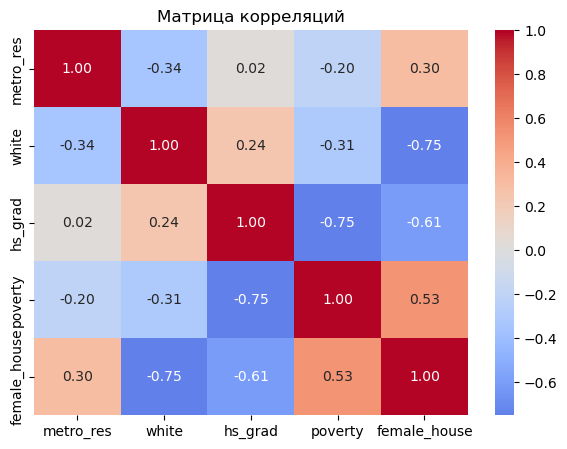

In [493]:
import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, 
            annot=True,  # показывать значения в ячейках
            fmt=".2f",   # формат чисел (2 знака после запятой)
            cmap='coolwarm',  # цветовая схема
            center=0)    # центр цветовой шкалы
plt.title('Матрица корреляций')
plt.show()

In [495]:
import statsmodels.formula.api as sm

result = sm.ols(formula="poverty ~ metro_res + white + hs_grad", data=state_data).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                poverty   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.618
Method:                 Least Squares   F-statistic:                     28.00
Date:                Sun, 06 Jul 2025   Prob (F-statistic):           1.55e-10
Time:                        12:49:24   Log-Likelihood:                -103.41
No. Observations:                  51   AIC:                             214.8
Df Residuals:                      47   BIC:                             222.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     68.7220      6.389     10.756      0.0

После исключения переменной female_house, которая имела высокую мультиколлинеарность с остальными переменными:

**Переменная white стала статистически значимой (P>|t| < 0.05)**

**Модель стала лучше описывать данные(показатель Adj. R увеличился до 61.8%)**

**Финальная формула модели: Y = 68.7 - 0.05metro_res - 0.05white - 0.57hs_grad**

In [498]:
params = sm.ols(formula="poverty ~ metro_res + white + hs_grad", data=state_data).fit().params
params

Intercept    68.722015
metro_res    -0.055532
white        -0.053327
hs_grad      -0.569724
dtype: float64

C:\Users\ryagu\AppData\Local\Temp\ipykernel_16496\1702182639.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = params[0] + params[1]*state_data['metro_res'] + params[2]*state_data['white'] + params[3]*state_data['hs_grad']


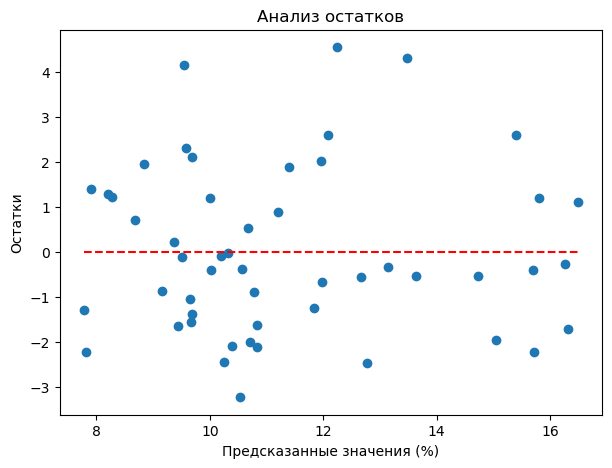

In [502]:
#residuals = sm.ols(formula="poverty ~ metro_res + white + hs_grad", data=state_data).fit().resid
y_pred = params[0] + params[1]*state_data['metro_res'] + params[2]*state_data['white'] + params[3]*state_data['hs_grad']
residuals = state_data['poverty'] - y_pred
fig = plt.figure(figsize = (7,5))
plt.scatter(y_pred, residuals)
sns.lineplot(x=y_pred, y=0, linestyle='--', color='r')
plt.title('Анализ остатков')
plt.xlabel('Предсказанные значения (%)')
plt.ylabel('Остатки')
plt.show()

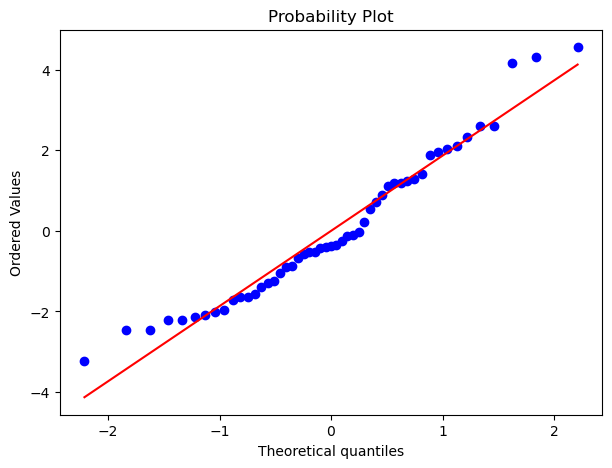

In [436]:
fig = plt.figure(figsize = (7,5))
stats.probplot(residuals, dist='norm', plot=plt)
plt.show()

Распределение остатков достаточно симметрично, изменчивость постоянна, распределение близко к нормальному(расположение точек на прямой QQ-plot). Следовательно модель надежна.

In [516]:
'''Основываясь на итоговой регрессионной модели, давайте вновь выполним задачу предсказания. 
Какой процент людей, проживающих в бедности, ожидается, если :
процент людей со средним образованием (hs_grad) равен 90;                          
процент людей, проживающих в столичной области (metro_res), равен 80;                     
процент белокожего населения (white) равен 50.'''
b0 = 68.7
b1 = -0.05
b2 = -0.06
b3 = -0.57

hs_grad_1 = 90
metro_res_1 = 80
white_1 = 50
y_pred_1 = b0 + b1 * metro_res_1 + b2 * white_1 + b3 * hs_grad_1
y_pred_1

10.400000000000006